In [10]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from idlpy import *
import cartopy.crs as ccrs
import cartopy.feature as cf
import matplotlib as mpl
from pylab import *

In [2]:
def get_linregress_slope(arr):
    if (np.isnan(arr)).any():
        result = np.nan
    else:
        result = np.polyfit([i for i in range(len(arr))],arr,deg=1)[0]
        
    return(result)


In [3]:
def get_obs_data(box, vege_mask_flag):
         
    
    #d4pdf = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/fire/d4pdf/FWI/95percentile/BC_wind_FWI/BC_wind_95_p_FWI_HPB_ensMean.nc')
    d4pdf = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/fire/d4pdf/FWI/6month_fire_season/BC_wind_FWI/BC_wind_FWI_HPB_ensMean.nc')

    #da = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/fire/ERA5/model-style/95percentile/d4pdf_resolution/ERA5_FWI_95p_d4pdf_resolution.nc')
    da = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/fire/ERA5/model-style/6month_fire_season/d4pdf_resolution/FWI_6month_fire_season_d4pdf_resolution.nc')
    if box != 'full':
        da = da.sel(latitude=slice(box[0][0],box[0][1]),longitude=slice(box[1][0],box[1][1]))

    if vege_mask_flag:
        da = da.where(vege_mask>0)
        
    da = da.sel(time=slice("1951","2021"))
    da = da.where(~d4pdf.isnull())
    
    da = da.stack(pixel=("latitude", "longitude"))
    da = da.dropna("pixel", how="all")        
    
    array = da.values.flatten()
    
    del da
    
    return(array)


In [4]:
def get_mean_and_noise(scen, box, vege_mask_flag):
    
    # 95th percentile
    #era5_da = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/fire/ERA5/model-style/95percentile/d4pdf_resolution/ERA5_FWI_95p_d4pdf_resolution.nc')
    # 6-month fire season
    era5_da = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/fire/ERA5/model-style/6month_fire_season/d4pdf_resolution/FWI_6month_fire_season_d4pdf_resolution.nc')
    
    # 95th percentile
    #ens_mean = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/fire/d4pdf/FWI/95percentile/BC_wind_FWI/BC_wind_95_p_FWI_'+scen+'_ensMean.nc')
    # 6-month fire season
    ens_mean = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/fire/d4pdf/FWI/6month_fire_season/BC_wind_FWI/BC_wind_FWI_'+scen+'_ensMean.nc')
    
    if box != 'full':
        ens_mean = ens_mean.sel(latitude=slice(box[0][0],box[0][1]),longitude=slice(box[1][0],box[1][1]))

    if vege_mask_flag:
        ens_mean = ens_mean.where(vege_mask>0)
        
    ens_mean = ens_mean.sel(time=slice("1951","2021"))
    ens_mean = ens_mean.where(~era5_da.isnull())
    
    noise = []
    for ens_mem in range(1,101):
        if ens_mem == 100:
            number = '100'
        else:
            number = '00' + str(ens_mem) if ens_mem < 10 else '0' + str(ens_mem)

        #mem_da = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/fire/d4pdf/FWI/95percentile/BC_wind_FWI/BC_wind_95_p_FWI_'+scen+'_m'+number+'.nc')
        mem_da = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/fire/d4pdf/FWI/6month_fire_season/BC_wind_FWI/BC_wind_FWI_'+scen+'_m'+number+'.nc')

        if box != 'full':
            mem_da = mem_da.sel(latitude=slice(box[0][0],box[0][1]),longitude=slice(box[1][0],box[1][1]))

        if vege_mask_flag:
            mem_da = mem_da.where(vege_mask>0)

        mem_da = mem_da.sel(time=slice("1951","2021"))
        mem_da = mem_da.where(~era5_da.isnull())

        diff = mem_da - ens_mean

        diff = diff.stack(pixel=("latitude", "longitude"))# Create a MultiIndex
        diff = diff.dropna("pixel", how="all")# Drop the pixels that only have NA values.
                
        diff_array = diff.values.flatten()
        noise.append(diff_array)
        
        del mem_da
        del diff_array

    ens_mean = ens_mean.stack(pixel=("latitude", "longitude"))# Create a MultiIndex
    ens_mean = ens_mean.dropna("pixel", how="all")# Drop the pixels that only have NA values.
    ens_mean_array = ens_mean.values.flatten()

    del ens_mean
    
    return((ens_mean_array, np.array(noise)))


In [5]:
def plot_result(scan_beta_est):

    fig,axs = plt.subplots(figsize=(12,10))

    for j in range(len(scan_beta_est)):

        beta_est = scan_beta_est[j]
        best_1,low_1,up_1 = beta_est[0][0],beta_est[1][0],beta_est[2][0]
        best_2,low_2,up_2 = beta_est[0][1],beta_est[1][1],beta_est[2][1]

        axs.scatter([j+3]*3,[low_2,best_2,up_2],c='blue',alpha=0.7,label='nat' if j == 0 else '')
        axs.scatter([j+3]*3,[low_1,best_1,up_1],c='red',label='ant' if j == 0 else '')

        axs.vlines(j+3,low_2,up_2,colors=['blue'])
        axs.vlines(j+3,low_1,up_1,colors=['red'])

        axs.axhline(0,-0.5,1.5)
        axs.axhline(1,-0.5,1.5)

    axs.legend()
    axs.set_ylim(-1,4)

    plt.title('BC ERA5/d4pdf fire season FWI (1951-2021)')
    #plt.savefig('/nesi/project/niwa00015/queenle/plots/fire/era5_fingerprinting/FWI/6month_fire_season/'+resample_interval+'/result.png')
    plt.show()
    #plt.close(fig)
    

In [6]:
'''
Create vegetation land mask
'''

vege_ds = xr.open_dataset('/nesi/project/niwa00015/queenle/data/ERA5/monthly/vegetation/1951-2021.nc')
vege_ds['longitude'] = [lon + 360 for lon in vege_ds.longitude.data]

d4pdf_da = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/fire/d4pdf/FWI/6month_fire_season/BC_wind_FWI/BC_wind_FWI_HPB_ensMean.nc')

vege_ds = vege_ds.coarsen(latitude=3,longitude=3,boundary='pad').mean()
vege_ds = vege_ds.interp(longitude=d4pdf_da.longitude, latitude=d4pdf_da.latitude, method="linear")

full_lai = vege_ds.lai_hv + vege_ds.lai_lv
full_lai_max = full_lai.max('time')

vege_mask = full_lai_max.where(full_lai_max>3.5)


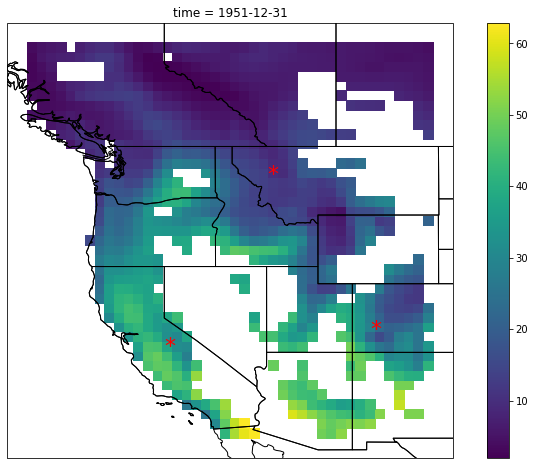

In [8]:
box = [(32,55),(232,256)]

da = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/fire/ERA5/model-style/6month_fire_season/d4pdf_resolution/FWI_6month_fire_season_d4pdf_resolution.nc')
da = da.sel(latitude=slice(box[0][0],box[0][1]),longitude=slice(box[1][0],box[1][1]))
da = da.where(vege_mask>0)
da = da.sel(time=slice("1951","2021"))

fig, axs = plt.subplots(1, 1, figsize=(12,8),subplot_kw=dict(projection=ccrs.PlateCarree()))

da.isel(time=0).plot(ax=axs,transform=ccrs.PlateCarree())
axs.coastlines()  # cartopy function
axs.add_feature(cf.BORDERS)
axs.add_feature(cf.STATES)

western_Montana = [47,246]
Colorado = [38,252]
central_California = [37,240]

axs.text(western_Montana[1],western_Montana[0],'*',c='red',size=22,transform=ccrs.PlateCarree())#, transform=axs.transAxes)
axs.text(Colorado[1],Colorado[0],'*',c='red',size=22,transform=ccrs.PlateCarree())#, transform=axs.transAxes)
axs.text(central_California[1],central_California[0],'*',c='red',size=22,transform=ccrs.PlateCarree())#, transform=axs.transAxes)

plt.show()
plt.close(fig)

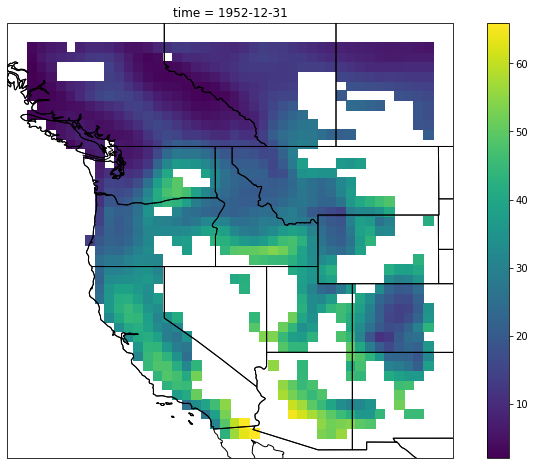

getting ALL mean and noise
getting NAT mean and noise
getting Ant mean and noise
getting obs
got obs
got arrays
running gendetec


In [49]:
'''
OF at one truncation for FINGER_TRUNC output
'''

#boxes = ['full',[(32,55),(232,256)]]#,[(32,55),(232,250)],[(32,55),(235,245)]]
boxes = [[(32,55),(232,256)]]

for vege_mask_flag in [True]:
    for box in boxes:

        #da = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/fire/ERA5/model-style/95percentile/d4pdf_resolution/ERA5_FWI_95p_d4pdf_resolution.nc')
        da = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/fire/ERA5/model-style/6month_fire_season/d4pdf_resolution/FWI_6month_fire_season_d4pdf_resolution.nc')
        if box != 'full':
            da = da.sel(latitude=slice(box[0][0],box[0][1]),longitude=slice(box[1][0],box[1][1]))
        if vege_mask_flag:
            da = da.where(vege_mask>0)
        da = da.sel(time=slice("1951","2021"))
        
        fig, axs = plt.subplots(1, 1, figsize=(12,8),subplot_kw=dict(projection=ccrs.PlateCarree()))

        da.isel(time=1).plot(ax=axs,transform=ccrs.PlateCarree())
        axs.coastlines()  # cartopy function
        axs.add_feature(cf.BORDERS)
        axs.add_feature(cf.STATES)

        plt.show()
        plt.close(fig)


        IDL.retall

        print('getting ALL mean and noise')
        all_ens_mean,noise_all = get_mean_and_noise('HPB', box, vege_mask_flag)
        print('getting NAT mean and noise')
        nat_ens_mean,noise_nat = get_mean_and_noise('HPB_NAT', box, vege_mask_flag)
        print('getting Ant mean and noise')
        ant_ens_mean,noise_ant = get_mean_and_noise('Ant', box, vege_mask_flag)

        print('getting obs')
        data_obs = get_obs_data(box, vege_mask_flag)
        print('got obs')
        data_scen = np.array([ant_ens_mean,nat_ens_mean])

        data_noise_1 = np.concatenate((noise_all[:50],noise_nat[:50]))
        data_noise_2 = np.concatenate((noise_all[50:],noise_nat[50:]))

        print('got arrays')

        trunc = 60
        
        IDL.data_obs = data_obs
        IDL.data_scen = data_scen
        IDL.data_noise_1 = data_noise_1
        IDL.data_noise_2 = data_noise_2
        IDL.trunc = trunc
        IDL.finger_trans = 1
        IDL.z_best = 1

        print('running gendetec')
        #IDL.run("gendetec, data_obs, data_scen, data_noise_1, beta_est, \
        #        data_noise_2=data_noise_2,transform=['1*0','1*0+1*1'], trunc=trunc, finger_trans=finger_trans")
        IDL.run("gendetec, data_obs, data_scen, data_noise_1, beta_est, \
                data_noise_2=data_noise_2, trunc=trunc, finger_trans=finger_trans, z_best=z_best")

        finger_trans = IDL.finger_trans
        z_best = IDL.z_best

        beta_est = IDL.BETA_EST

        best_ant,low_ant,up_ant = beta_est[0][0],beta_est[1][0],beta_est[2][0]
        best_nat,low_nat,up_nat = beta_est[0][1],beta_est[1][1],beta_est[2][1]

        da.close()

In [52]:
beta_est

array([[1.5069969 , 0.7155883 ],
       [0.9245844 , 0.61623156],
       [2.0894094 , 0.814945  ]], dtype=float32)

In [53]:
'''
create dataset with d4pdf All, Nat, Ant signals and Nat and Ant fingerprints from finger_trans
'''

era5_da = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/fire/ERA5/model-style/6month_fire_season/d4pdf_resolution/FWI_6month_fire_season_d4pdf_resolution.nc')
box = [(32,55),(232,256)]

All_da = xr.open_dataset('/nesi/project/niwa00015/queenle/data/fire/d4pdf/FWI/6month_fire_season/BC_wind_FWI/BC_wind_FWI_HPB_ensMean.nc')
All_da = All_da.rename({'FWI':'All'})
Nat_da = xr.open_dataset('/nesi/project/niwa00015/queenle/data/fire/d4pdf/FWI/6month_fire_season/BC_wind_FWI/BC_wind_FWI_HPB_NAT_ensMean.nc')
Nat_da = Nat_da.rename({'FWI':'Nat'})

d4pdf_ds = xr.merge([All_da,Nat_da])
d4pdf_ds = d4pdf_ds.assign(Ant=d4pdf_ds.All - d4pdf_ds.Nat)

d4pdf_ds = d4pdf_ds.sel(latitude=slice(box[0][0],box[0][1]),longitude=slice(box[1][0],box[1][1]))
d4pdf_ds = d4pdf_ds.where(vege_mask>0)
d4pdf_ds = d4pdf_ds.sel(time=slice("1951","2021"))
d4pdf_ds = d4pdf_ds.where(~era5_da.isnull())

d4pdf_pixel = d4pdf_ds.stack(pixel=("latitude", "longitude"))
d4pdf_no_nan = d4pdf_pixel.dropna("pixel", how="all")

# add fingerprints
ant_finger_trans = np.array([val[1] for val in finger_trans])
nat_finger_trans = np.array([val[0] for val in finger_trans])

z_best_ant_finger = np.array(z_best[0])
z_best_nat_finger = np.array(z_best[1])

z_best_obs = np.array(z_best[2])

d4pdf_add_fingers = d4pdf_no_nan.assign(ant_finger_trans=(['time','lev','pixel'],ant_finger_trans.reshape(71,1,958)),
                                      nat_finger_trans=(['time','lev','pixel'],nat_finger_trans.reshape(71,1,958)),
                                      ant_finger_from_zbest=(['time','lev','pixel'],z_best_ant_finger.reshape(71,1,958)),
                                      nat_finger_from_zbest=(['time','lev','pixel'],z_best_nat_finger.reshape(71,1,958)),
                                      est_obs_from_zbest=(['time','lev','pixel'],z_best_obs.reshape(71,1,958)))

d4pdf_unstack = d4pdf_add_fingers.unstack("pixel")

d4pdf_final = d4pdf_unstack.assign(nat_finger_from_trans = (1/(d4pdf_unstack['nat_finger_trans']+1))-1,
                                 ant_finger_from_trans = (1/(d4pdf_unstack['ant_finger_trans']+1))-1)



In [60]:
z_best_ant_finger = np.array(z_best[0])
z_best_nat_finger = np.array(z_best[1])

z_best_obs = np.array(z_best[2])


print(z_best_ant_finger)
print('')
print(z_best_nat_finger)
print('\n\n\n')
print('')
print(z_best_obs)
print('')

print(best_ant*z_best_ant_finger+best_nat*z_best_nat_finger)
print('')


[-0.09061939 -0.32766311 -0.50698051 ...  0.07894585  0.09701969
  0.02708513]

[ 0.6731197  -1.24223707 -2.48641542 ... -1.00950243 -0.97363998
 -1.53011733]





[ 0.34511341 -1.38271755 -2.54326773 ... -0.60341693 -0.55051697
 -1.05411679]

[ 0.34511342 -1.38271756 -2.54326776 ... -0.60341695 -0.55051699
 -1.05411682]



In [58]:
print(z_best_ant_finger)
print('')
print(z_best_nat_finger)
print('')
print(z_best_obs)
print('')

[-0.09061939 -0.32766311 -0.50698051 ...  0.07894585  0.09701969
  0.02708513]

[ 0.6731197  -1.24223707 -2.48641542 ... -1.00950243 -0.97363998
 -1.53011733]

[ 0.34511341 -1.38271755 -2.54326773 ... -0.60341693 -0.55051697
 -1.05411679]



In [ ]:
ant = d4pdf_final['ant_finger_from_trans'].sel(latitude=Colorado[0],longitude=Colorado[1],method='nearest')
nat = d4pdf_final['nat_finger_from_trans'].sel(latitude=Colorado[0],longitude=Colorado[1],method='nearest')

scaled_ant = ant*best_ant
scaled_nat = nat*best_nat

est_obs = scaled_ant + scaled_nat

ant.plot()
nat.plot()
plt.show()
plt.close(fig)

scaled_ant.plot()
scaled_nat.plot()
plt.show()
plt.close(fig)

est_obs.plot()

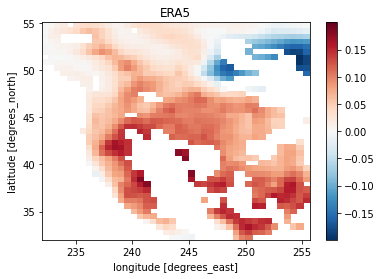

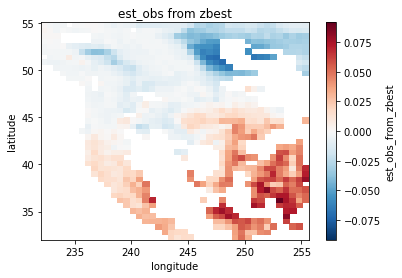

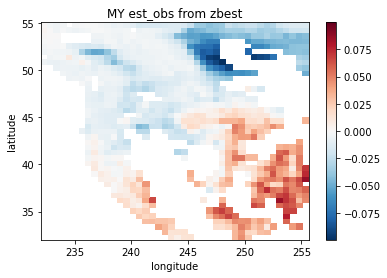

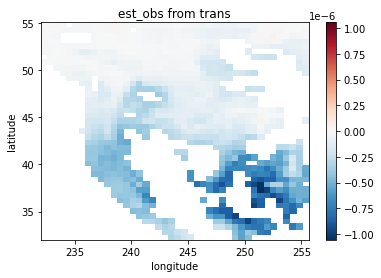

In [42]:
box = [(32,55),(232,256)]
da = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/fire/ERA5/model-style/6month_fire_season/d4pdf_resolution/FWI_6month_fire_season_d4pdf_resolution.nc')
da = da.sel(latitude=slice(box[0][0],box[0][1]),longitude=slice(box[1][0],box[1][1]))
da = da.where(vege_mask>0)
da = da.sel(time=slice("1959","2014"))

my_zbest_est_obs = d4pdf_final['ant_finger_from_zbest'] + d4pdf_final['nat_finger_from_zbest']

est_obs_trans = best_ant * d4pdf_final['ant_finger_from_trans'] + best_nat * d4pdf_final['nat_finger_from_trans']

xr.apply_ufunc(get_linregress_slope, da, input_core_dims=[["time"]], vectorize = True).plot()#ax=axs[i],transform=ccrs.PlateCarree(),vmin=rnge[0],vmax=rnge[1],cmap=cmap)
plt.title('ERA5')
plt.show()
plt.close(fig)

xr.apply_ufunc(get_linregress_slope, d4pdf_final['est_obs_from_zbest'], input_core_dims=[["time"]], vectorize = True).plot()#ax=axs[i],transform=ccrs.PlateCarree(),vmin=rnge[0],vmax=rnge[1],cmap=cmap)
plt.title('est_obs from zbest')
plt.show()
plt.close(fig)

xr.apply_ufunc(get_linregress_slope, my_zbest_est_obs, input_core_dims=[["time"]], vectorize = True).plot()#ax=axs[i],transform=ccrs.PlateCarree(),vmin=rnge[0],vmax=rnge[1],cmap=cmap)
plt.title('MY est_obs from zbest')
plt.show()
plt.close(fig)

xr.apply_ufunc(get_linregress_slope, est_obs_trans, input_core_dims=[["time"]], vectorize = True).plot()#ax=axs[i],transform=ccrs.PlateCarree(),vmin=rnge[0],vmax=rnge[1],cmap=cmap)
plt.title('est_obs from trans')
plt.show()
plt.close(fig)



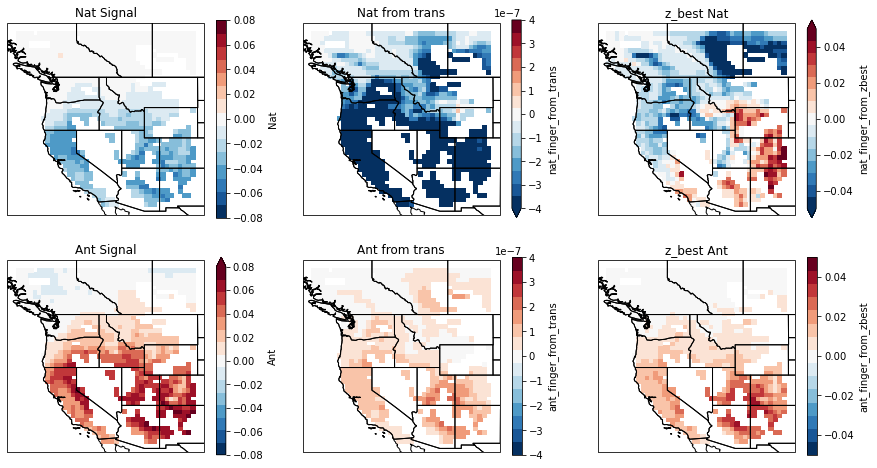

In [43]:
'''
plot Nat + Ant signals versus fingerprints
'''

fig,axs = plt.subplots(2,3,figsize=(15,8),sharex=True,sharey=True,subplot_kw=dict(projection=ccrs.PlateCarree()))
axs = axs.flatten()

titles = ['Nat Signal','Nat from trans','z_best Nat','Ant Signal','Ant from trans','z_best Ant']
for i,var in enumerate(['Nat','nat_finger_from_trans','nat_finger_from_zbest','Ant','ant_finger_from_trans','ant_finger_from_zbest']):
    
    if i in [0,3]:
        rnge = [-0.08,0.08] 
    elif i in [1,4]:
        rnge = [-.4e-6,.4e-6]
    elif i in [2,5]:
        rnge = [-0.05,0.05] 
    
    cmap = cm.get_cmap('RdBu_r', 15)
    
    xr.apply_ufunc(get_linregress_slope, d4pdf_final[var], input_core_dims=[["time"]], vectorize = True).plot(ax=axs[i],transform=ccrs.PlateCarree(),vmin=rnge[0],vmax=rnge[1],cmap=cmap)

    axs[i].coastlines()  # cartopy function
    axs[i].add_feature(cf.BORDERS)
    axs[i].add_feature(cf.STATES)
    axs[i].set_title(titles[i])


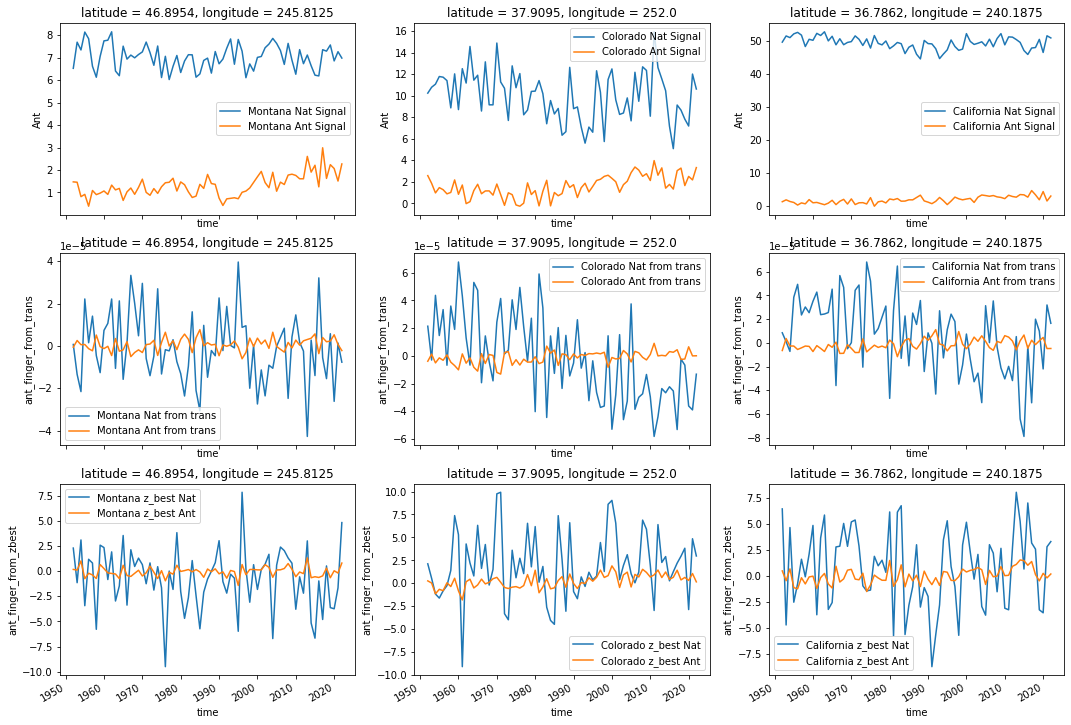

In [44]:
western_Montana = [47,246]
Colorado = [38,252]
central_California = [37,240]

titles = ['Nat Signal','Nat from trans','z_best Nat','Ant Signal','Ant from trans','z_best Ant']


fig,axs = plt.subplots(3,3,figsize=(18,12),sharex=True)
titles = ['Nat Signal','Ant Signal','Nat from trans','Ant from trans','z_best Nat','z_best Ant']
labels = ['Montana','Colorado','California']
for i,var in enumerate(['Nat','Ant','nat_finger_from_trans','ant_finger_from_trans','nat_finger_from_zbest','ant_finger_from_zbest']):
    
    da = d4pdf_final[var]
    
    montana_cell = da.sel(latitude=western_Montana[0],longitude=western_Montana[1],method='nearest')
    colorado_cell = da.sel(latitude=Colorado[0],longitude=Colorado[1],method='nearest')
    california_cell = da.sel(latitude=central_California[0],longitude=central_California[1],method='nearest')

    for j,cell in enumerate([montana_cell,colorado_cell,california_cell]):
        if i < 2:
            row = 0 
        elif i < 4:
            row = 1
        else:
            row = 2
            
        cell.plot(ax=axs[row][j],label=labels[j] + ' ' + titles[i])
        axs[row][j].legend()
